Ripetiamo la classificazione delle immagini in TEST2 con una rete ResNet addestrata (Transfer Learning)

Testato con monai 1.5.2, torchvision 0.24, torchmetrics 1.8.2, matplotlib 3.10.8, torchinfo 1.8.0,  tqdm 4.67.2, scikit-learn 1.8.0

# Transfer Learning - Notebook 6.5

In [2]:
import os
import numpy as np

# Import torch
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import datasets, transforms
from torchmetrics import Accuracy

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

2.8.0


Verifichiamo se il computer su cui gira il codice ha una GPU compatibile (e se pytorch è installato in modo corretto), altrimenti usiamo la CPU. Per MacOS su piattaforma sylicon usare 'mps' invece di 'cuda'  

In [3]:
# Setup device agnostic code
device = torch.device("cuda")
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Definiamo un seed per la generazione di numeri pseudo-random. I risultati dipenderanno dal seed quindi è importante mantenerlo costante in tutte le prove 

In [4]:
SEED = 42

Definiamo la cartella che contiene i dati. La cartella TEST2 le solite immagini d idue croci leggermente diverse 

In [5]:
# Load the data
# Setup path to data folder
from pathlib import Path
image_path = Path(r"C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2")   # root of data directory

Definiamo una funzione che descrive il contenuto della cartella dati 

In [6]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images \
          in '{dirpath}'.")   

walk_through_dir(image_path)  # show data structure

There are 2 directories and 0 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2'.
There are 0 directories and 1000 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2\C1'.
There are 0 directories and 1000 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2\C2'.


Nell'addestramento di modelli AI tipicamente utilizziamo un numero molto alto di mmagini, non possiamo caricarle tutte in memoria. Quindi si usa un 'dataloader' che indicizza le immagini e le importa 'al volo' quando necessario. Definiamo la funzione che legge le immagini dal disco e le porta in memoria. In questo caso la funzione interpola le immagini e le trasforma in tensori che è il formato usato da Pytorch. L'interpolazione serve per ottenere immagini della stessa dimensione (qui non serve, ma in generale le immagini che usiamo potrebbero avere dimensioni diverse) ed eventualmente per ridurre l'occupazione di memoria con un sottocampionamento. Il formato tensor ottimizza le prestazioni su GPU.  
In questa implemetazione utilizziamo un validation set per monitorare l'addestramento, quindi le funzioni saranno due, uan per il training ed una per il validation/test. Questo perchè la funzione per il training potrebbe contenere le operazioni di data augmentation "on the fly".    


In [7]:
# Write transform for turning images into tensors
train_data_transform = transforms.Compose([
    # Turn the image into a torch.Tensor
    transforms.Resize(size=(32,32)),
    # transforms.RandomHorizontalFlip(p=0.5) # data augmentation on-the-fly (flip image with 50% probability
    # transforms.RandomVerticalFlip(p=0.5) # data augmentation on-the-fly (flip image with 50% probability
    transforms.ToTensor() # converts all pixel values from 0-255 to be between 0-1
])

val_data_transform = transforms.Compose([
    # Turn the image into a torch.Tensor
    transforms.Resize(size=(32,32)),
    transforms.ToTensor() # converts all pixel values from 0-255 to be between 0-1
])

Carichiamo i dati, o meglio creiamo una struttura che indicizza la posizione dei dati sul disco, come detto prima all_data conterrà la posizione delle immagini e non le immagini. In questo caso target_transform è nulla perchè le label sono di tipo testuale. 

In [8]:
# load data by ImageFolder
all_data = datasets.ImageFolder(root=image_path, # target folder of images 
                                transform=val_data_transform, # transforms to 
                                                            # perform on data 
                                                            # (images)
                                target_transform=None) # transforms to 
                                                         # perform on labels 
                                                         # (if necessary)

Dividiamo i dati in training set e test set in modo casuale. Il test set sarà il 10% del totale.

In [9]:
# split data set in train, validation, and test: test = 10% de idati, validation 10% dei dati rimanenti
train_dataset, val_dataset, test_dataset = random_split(all_data, [1620, 180, 200])
train_dataset.transform=train_data_transform # change training transform

Creiamo i dataLoader, cioè le strutture che verranno usate per l'accesso alle immagini. Usiamo un batch_size=64 per il training con shuffle per utilizzare tutti i dati. Il batch_size di default è 1, che non permette di addestrare la N in modo efficace. Avendo 1800 immagini, avremo 28 batch "completi" con uan rimanenza di 8 immagini, per cui usiamo lo shuffle per rimescolare le immagini ad ogni epoca ed utilizzare così anche queste otto immagini nel training. Se drop_last=False le otto immagini vengono inserite in un bath "incompleto" usato nel training. Per il test possiamo usare qualsiasi valore contenuto un numero esatto di volte nel test set visto che viene usato solo in inference mode. 

In [10]:
# create dataloaders batches
batch_size=64
train_dataloader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,drop_last=True,)
val_dataloader = DataLoader(val_dataset,batch_size=1)
test_dataloader = DataLoader(test_dataset,batch_size=1)

# How many batches of images are in our data loaders?
print('Numero batch immagini di train: ',len(train_dataloader),' Numero batch immagini di validation: ', len(val_dataloader),' Numero batch immagini di test: ', len(test_dataloader))
     
class_names = all_data.classes # load class names
print('Nome delle classi: ',class_names)

Numero batch immagini di train:  25  Numero batch immagini di validation:  180  Numero batch immagini di test:  200
Nome delle classi:  ['C1', 'C2']


Usiamo il data loader per visualizzare alcune immagini.  

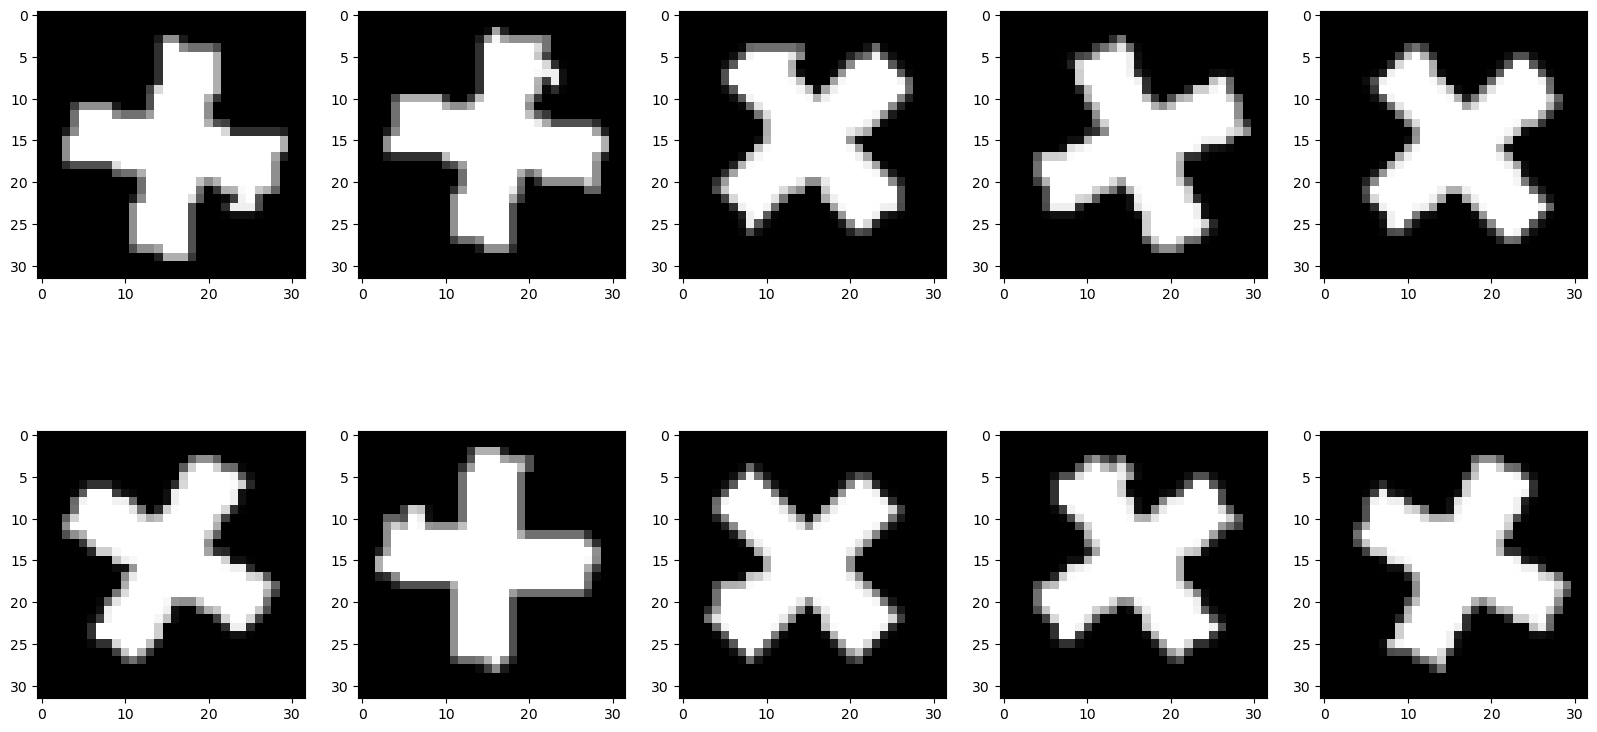

In [11]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2,5,figsize=(20,10)) # note we must use plt.subplots, not plt.subplot
for im in range(10): 
    i=im//5
    j=im-i*5
    img_label=train_dataset[im] ## extract image/label touple from dataset
    img=img_label[0] # RGB image 3x64x64
    img = np.moveaxis(img.numpy(), 0, 2) # matplotlib requires 64x64x3 format
    img = axs[i,j].imshow(img,cmap='gray')

Definiamo la dimensione dei dati di input al classificatore. Le immagini devono avere tutte la stessa dimensione

In [12]:
img=train_dataset[0]  # extract image/label touple from dataset
img_size=img[0].shape  # image size
print('image size = ',img_size)

image size =  torch.Size([3, 32, 32])


Definiamo la CNN come modulo Pytorch. La CNN che utilizziamo è una efficientnet addestrata al riconoscimento di immagini. Tra le varie versioni importiamo quella più semplice per motivi computazionali. Carichiamo l'architettura della rete e i pesi (quindi i parametri) che rappresentano la "conoscenza" acquisita dalla rete durante l'addestramento sul database ImageNet. Come si vede, anche la versione più semplice di efficientnet ha moltissimi parametri, per cui addestrarla da zero sarebbe molto impegnativo.    

In [13]:
# define CNN model 
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Best available weights (currently alias for IMAGENET1K_V2)
# Note that these weights may change across versions
model=efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT).to(device)
 

In [14]:
from torchinfo import summary
summary(model, 
        input_size=(batch_size, 3, img_size[1], img_size[2]), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        device='cpu',
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [64, 3, 32, 32]      [64, 1000]           --                   True
├─Sequential (features)                                      [64, 3, 32, 32]      [64, 1280, 1, 1]     --                   True
│    └─Conv2dNormActivation (0)                              [64, 3, 32, 32]      [64, 32, 16, 16]     --                   True
│    │    └─Conv2d (0)                                       [64, 3, 32, 32]      [64, 32, 16, 16]     864                  True
│    │    └─BatchNorm2d (1)                                  [64, 32, 16, 16]     [64, 32, 16, 16]     64                   True
│    │    └─SiLU (2)                                         [64, 32, 16, 16]     [64, 32, 16, 16]     --                   --
│    └─Sequential (1)                                        [64, 32, 16, 16]     [64, 16, 16,

Essendo addestrata su ImageNet, il modello esce con un array di 10000 score corrispondenti alle 10000 classi di oggetti su ImageNet. Non è quindi adatta ad essere usata nel nostro problema che è binario. Quindi dobbiamo modificarla opportunamente. Per prima cosa, "congeliamo" tutti i parametri della rete per non perdere la conoscenza acquisita.   

In [20]:
# frozen Features Extractor (depends on model)
for name, param in model.features.named_parameters():
    param.requires_grad = False

summary(model, 
        input_size=(batch_size, 3, img_size[1], img_size[2]), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        device='cpu',
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [64, 3, 32, 32]      [64, 1000]           --                   Partial
├─Sequential (features)                                      [64, 3, 32, 32]      [64, 1280, 1, 1]     --                   False
│    └─Conv2dNormActivation (0)                              [64, 3, 32, 32]      [64, 32, 16, 16]     --                   False
│    │    └─Conv2d (0)                                       [64, 3, 32, 32]      [64, 32, 16, 16]     (864)                False
│    │    └─BatchNorm2d (1)                                  [64, 32, 16, 16]     [64, 32, 16, 16]     (64)                 False
│    │    └─SiLU (2)                                         [64, 32, 16, 16]     [64, 32, 16, 16]     --                   --
│    └─Sequential (1)                                        [64, 32, 16, 16]     [64, 

Abbiamo congelato tutti i parametri tranne il classificatore finale che comunque dobbiamo modificare. Quindi procediamo cambiando il numero di classi di uscita dal classificatore.

In [26]:
# replace last layer (depends on model) 
model.classifier = torch.nn.Sequential(
        torch.nn.Dropout(p=0.2, inplace=True),
        torch.nn.Linear(in_features=1280, 
        out_features=len(class_names), # same number of output units as our number of classes
        bias=True)).to(device)

summary(model, 
        input_size=(batch_size, 3, img_size[1], img_size[2]), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        device='cpu',
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [64, 3, 32, 32]      [64, 2]              --                   Partial
├─Sequential (features)                                      [64, 3, 32, 32]      [64, 1280, 1, 1]     --                   False
│    └─Conv2dNormActivation (0)                              [64, 3, 32, 32]      [64, 32, 16, 16]     --                   False
│    │    └─Conv2d (0)                                       [64, 3, 32, 32]      [64, 32, 16, 16]     (864)                False
│    │    └─BatchNorm2d (1)                                  [64, 32, 16, 16]     [64, 32, 16, 16]     (64)                 False
│    │    └─SiLU (2)                                         [64, 32, 16, 16]     [64, 32, 16, 16]     --                   --
│    └─Sequential (1)                                        [64, 32, 16, 16]     [64, 

A questo punto abbiamo il nostro modello, che dovrebbe essere capace di estrarre features significative dalle immagini grazie alla sua conoscenza pregressa e classificarle attraverso l'ultimo strato che addestreremo. Notiamo che dobbiamo ottimizzare solo 2562 parametri invece dei milioni della efficientnet che abbiamo "congelato" 

Definito il modello dobbiamo definire la loss che useremo nell'addestramento (cross-entropy), l'ottimizzatore (Adam, un SDG otimmizzato) e la metrica da usare per verificare il buon funzionamento del modello (Accuratezza). Definiamo anche il learning rate dell'ottimizzatore (il passo di campionamento del search space) che è un parametro critico per la convergenza del training 

In [27]:
accuracy_fn = Accuracy(task='multiclass', num_classes=len(class_names)).to(device)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

loss_fn=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Definiamo la procedura di training, cioè qualla in cui vengono aggiornati i parametri. La procedura prende in ingresso il modello, i dati, la loss definita prima, l'ottimizzatore, la metrica e il device che usiamo (GPU o CPU).
Come si vede la procedura itera sui minibatch che sono stati definiti alla creazione del dataloader. Legge le coppie immagine/label dal dataloader e usa il modello per predirre il valore delle label (y_pred). Calcola la loss tra le label predette e quelle "vere". La loss si "accumula" lungo i batch. Quindi si "resetta" l'ottimizzatore. Si calcola il gradiente della loss (loss.backward()) e l'ottimizzatore cambia i parametri cercando di minimizzare la loss.
Alla fine si calcolano la loss e l'accuratezza sull epoca (tutti i minibatch sono stati analizzati) 

In [28]:
# define train procedure
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device):
    train_loss, train_acc = 0, 0
    
    model.to(device)  # load the model on GPU or CPU
    
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_pred.argmax(dim=1), # logits -> pred labels
                                 y).to(device)

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    #print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
    return train_loss, train_acc 

Definiamo la procedura di test sul validation set, che è analoga a quella di train ma avviene in inference mode, e quindi i parametri del modello non cambiano. La procedura prende in ingresso il modello, i dati, la loss definita prima, la metrica e il device che usiamo (GPU o CPU).
Come si vede la procedura itera sui minibatch che sono stati definiti alla creazione del dataloader. Legge le coppie immagine/label dal dataloader e usa il modello per predirre il valore delle label (y_pred). Calcola la loss tra le label predette e quelle "vere". La loss si "accumula" lungo i batch. Alla fine si calcolano la loss e l'accuratezza sull epoca (tutti i minibatch sono stati analizzati) 

In [29]:
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(test_pred.argmax(dim=1), y).to(device)
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        #print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")
        return test_loss, test_acc 

Definiamo adesso l'intera procedura di training, che itera su un certo numero di epoche chiamando le procedure definite prima e salva i valori di loss e accuratezza per il train ed i lvalidation set in una struttura.

In [30]:
def train(accuracy_fn,
          device,
          model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          ):
  
  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "val_loss": [],
             "val_acc": []}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model, 
                                       data_loader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       accuracy_fn=accuracy_fn,
                                       device=device)
    # Test step
    val_loss, val_acc = test_step(model=model, 
                                    data_loader=val_dataloader,
                                    loss_fn=loss_fn,
                                    accuracy_fn=accuracy_fn,
                                    device=device)
    
    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"val_loss: {val_loss:.4f} | "
          f"val_acc: {val_acc:.4f}"
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["val_loss"].append(val_loss)
    results["val_acc"].append(val_acc)

  # Save Trained Model
  print('Saving trained model....')
  torch.save(model, 'efficient_ECG_trained.pth')    
    
  # Return the results dictionary
  return results

Adesso possiamo eseguire il training del modello 

In [31]:
from tqdm.auto import tqdm
model_results = train(accuracy_fn=accuracy_fn,
                      device=device,
                      model=model,
                      train_dataloader=train_dataloader,
                      val_dataloader=val_dataloader,
                      optimizer=optimizer,
                      epochs=50)

  2%|▏         | 1/50 [00:09<07:44,  9.48s/it]

Epoch: 1 | train_loss: 0.7088 | train_acc: 0.5612 | val_loss: 0.7070 | val_acc: 0.5500


  4%|▍         | 2/50 [00:16<06:32,  8.19s/it]

Epoch: 2 | train_loss: 0.6478 | train_acc: 0.6344 | val_loss: 0.5907 | val_acc: 0.7000


  6%|▌         | 3/50 [00:24<06:05,  7.78s/it]

...

Epoch: 48 | train_loss: 0.1340 | train_acc: 0.9750 | val_loss: 0.2575 | val_acc: 0.9056


 98%|█████████▊| 49/50 [05:37<00:06,  6.74s/it]

Epoch: 49 | train_loss: 0.1288 | train_acc: 0.9775 | val_loss: 0.2600 | val_acc: 0.8833


100%|██████████| 50/50 [05:43<00:00,  6.87s/it]

Epoch: 50 | train_loss: 0.1299 | train_acc: 0.9756 | val_loss: 0.2470 | val_acc: 0.9167


Visualizziamo le curve di addestramento. Come si vede le curve di train e validation sono abbastanza vicine, suggerendo un moderato overfitting. Probabilmente aumentando il numero di epoche l'accuratezza sul training set andrebbe a uno ma non quella sul validation. 
Comunque la efficientnet performa bene su un tipo di immagini mai viste. Per migliorare le prestazioni dovremmo provare a "scongelare" altri strati della rete, tipicamente partendo dalla fine (ad esempio Conv2dNormActivation(8)).   

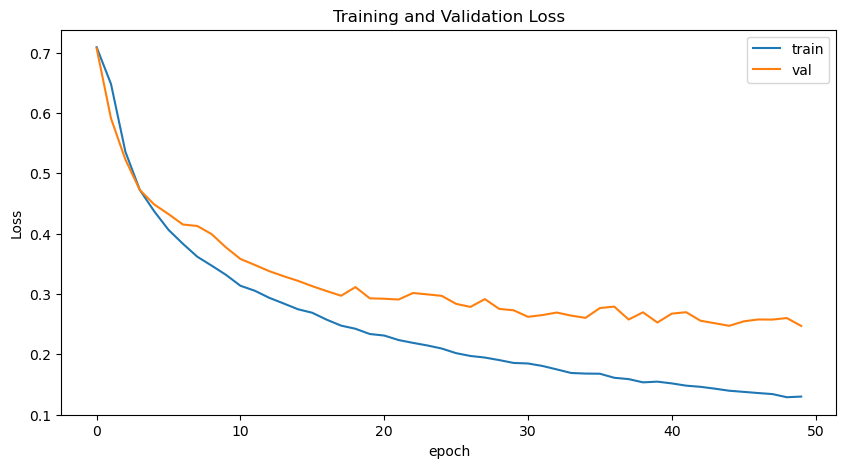

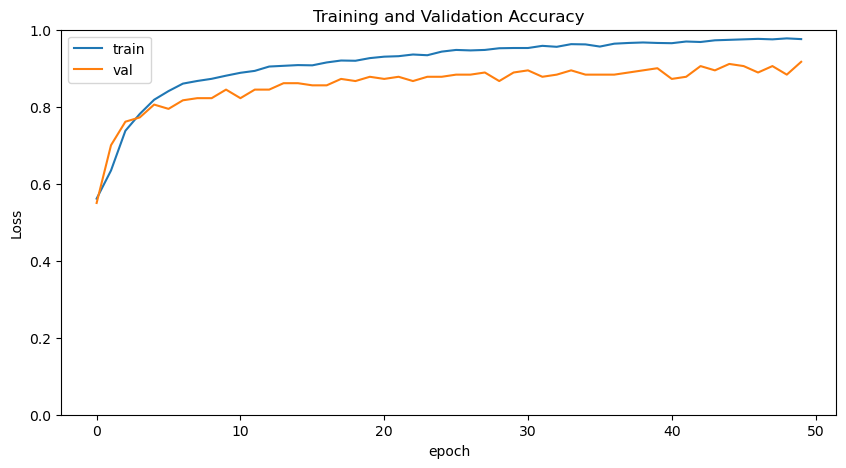

In [32]:
# plot training curves
np_train_loss = np.array([x.item() for x in model_results['train_loss']])
np_val_loss = np.array([x.item() for x in model_results['val_loss']])
np_train_acc = np.array([x.item() for x in model_results['train_acc']])
np_val_acc = np.array([x.item() for x in model_results['val_acc']])

plt.figure(figsize=(10,5))
plt.title("Training and Validation Loss")
plt.plot(np_train_loss,label="train")
plt.plot(np_val_loss,label="val")
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
plt.figure(figsize=(10,5))
plt.title("Training and Validation Accuracy")
plt.plot(np_train_acc,label="train")
plt.plot(np_val_acc,label="val")
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.ylim((0,1))
plt.legend()
plt.show()

Proviamo il modello addestrato sul training set. Ci mettiamo in inference_mode, cioè "congeliamo" i parametri del modello in modo che quando facciamo la predizione non vengano calcolat ii gradienti, questo ottimizza il tempo di calcolo.
Il modello nell'implementazione Pytorch restituisce degli score non normalizzati a uno per ottimizzare le prestazioni, quindi li normalizziamo a 1 con il softmax. Otteniamo il valore di accuratezza sul training set    


In [33]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

predictions = []
targets = []

with torch.inference_mode():
        for X, y in train_dataloader:
            X = X.to(device)
            y = y.to(device)
            y_logit = model(X)
            y_pred_prob = F.softmax(y_logit, dim=-1) # predicted probability
            y_pred_class = torch.argmax(y_pred_prob, dim=-1) # predicted class label
            predictions.extend(y_pred_class.tolist())
            targets.extend(y.tolist())

accuracy = accuracy_score(targets, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9775


Oltre all'accuratezza possiamo valutare altre metriche

In [34]:
from sklearn.metrics import classification_report
report = classification_report(targets, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       808
           1       0.97      0.98      0.98       792

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



Infine calcoliamo la confusion matrix

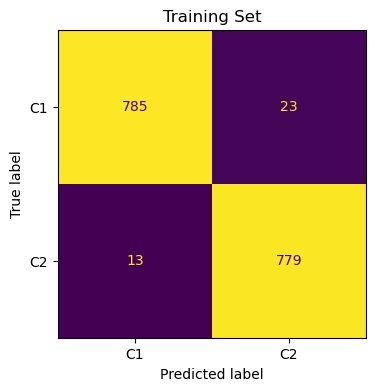

In [35]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrix = confusion_matrix(targets, predictions)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(targets, predictions, display_labels = class_names, colorbar=False,ax=ax)
ax.set_title('Training Set');

Nel training set otteniamo accuratezza 1 (tutte le immagini classificate correttamente). Ripetiamo la procedura per il validation set

Accuracy: 0.9166666666666666
              precision    recall  f1-score   support

           0       0.89      0.93      0.91        81
           1       0.94      0.91      0.92        99

    accuracy                           0.92       180
   macro avg       0.92      0.92      0.92       180
weighted avg       0.92      0.92      0.92       180



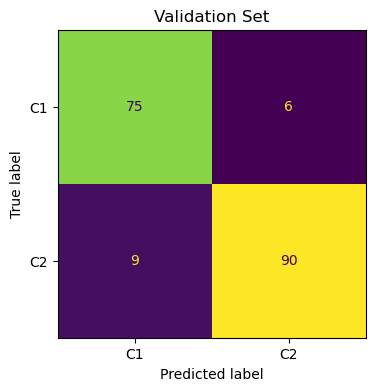

In [36]:
predictions = []
targets = []

model.eval()
with torch.inference_mode():
        for X, y in val_dataloader:
            X = X.to(device)
            y = y.to(device)
            y_logit = model(X)
            y_pred_prob = F.softmax(y_logit, dim=-1) # predicted probability
            y_pred_class = torch.argmax(y_pred_prob, dim=-1) # predicted class label
            predictions.extend(y_pred_class.tolist())
            targets.extend(y.tolist())

accuracy = accuracy_score(targets, predictions)
print("Accuracy:", accuracy)
report = classification_report(targets, predictions)
print(report)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrix = confusion_matrix(targets, predictions)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(targets, predictions, display_labels = class_names, colorbar=False,ax=ax)
ax.set_title('Validation Set');

Ripetiamo la procedura per il test set

Accuracy: 0.885
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       100
           1       0.89      0.88      0.88       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.88       200



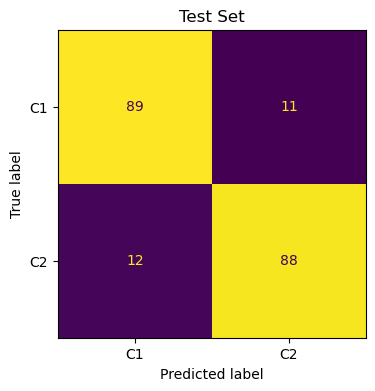

In [37]:
predictions = []
targets = []

model.eval()
with torch.inference_mode():
        for X, y in test_dataloader:
            X = X.to(device)
            y = y.to(device)
            y_logit = model(X)
            y_pred_prob = F.softmax(y_logit, dim=-1) # predicted probability
            y_pred_class = torch.argmax(y_pred_prob, dim=-1) # predicted class label
            predictions.extend(y_pred_class.tolist())
            targets.extend(y.tolist())

accuracy = accuracy_score(targets, predictions)
print("Accuracy:", accuracy)
report = classification_report(targets, predictions)
print(report)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrix = confusion_matrix(targets, predictions)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(targets, predictions, display_labels = class_names, colorbar=False,ax=ax)
ax.set_title('Test Set');

Quindi è possibile usare modelli addestrati per estrarre features significative da immagini diverse da quelle di ImageNet, anche immagini biomediche, con il vantaggio di ridurre sostanzialmente i tempi di addestramento. 